### Foucault Pendolum

The exact equations of motion for a Foucault pendulum, without any approximations, are given in vector form in a reference frame rotating with the Earth:

$$
    \ddot{\mathbf{r}} = \mathbf{g} - \frac{T}{m L} \mathbf{r} - 2\,\boldsymbol{\Omega} \times \dot{\mathbf{r}} - \boldsymbol{\Omega} \times (\boldsymbol{\Omega} \times \mathbf{r})
$$

The exact expression for the tension in a Foucault pendulum, derived from the vector equation of motion, is:

$$
    T = \frac{m}{L}\left[ \mathbf{r}\cdot\mathbf{g} - 2\,\mathbf{r}\cdot(\boldsymbol{\Omega}\times\dot{\mathbf{r}}) - (\boldsymbol{\Omega}\cdot\mathbf{r})^2 + \Omega^2 L^2 + |\dot{\mathbf{r}}|^2 \right]
$$

To get this, apply: 

$$
    |\mathbf{r}| = L ⇒ \mathbf{r}\cdot\mathbf{r} = L^2
$$

Differentiate once:

$$
    \mathbf{r}\cdot\dot{\mathbf{r}} = 0
$$

Differentiate again:

$$
    \dot{\mathbf{r}}\cdot\dot{\mathbf{r}} + \mathbf{r}\cdot\ddot{\mathbf{r}} = 0
    \quad\Rightarrow\quad
    \mathbf{r}\cdot\ddot{\mathbf{r}} = -|\dot{\mathbf{r}}|^2
$$

After substituting the exact expression for the tension into the equation of motion and simplifying, we obtain the following all-in equation:

$$
    \ddot{\mathbf{r}} = \mathbf{g} - \frac{1}{L^2}(\mathbf{r}\cdot\mathbf{g})\,\mathbf{r}
    + \frac{2}{L^2}\bigl[\mathbf{r}\cdot(\boldsymbol{\Omega}\times\dot{\mathbf{r}})\bigr]\,\mathbf{r}
    + \frac{1}{L^2}(\boldsymbol{\Omega}\cdot\mathbf{r})^2\,\mathbf{r}
    - \frac{1}{L^2}|\dot{\mathbf{r}}|^2\,\mathbf{r}
    - 2\,\boldsymbol{\Omega}\times\dot{\mathbf{r}}
    - \boldsymbol{\Omega}\,(\boldsymbol{\Omega}\cdot\mathbf{r})
$$

This formulation of the problem does not have a closed-form solution. We must apply some approximations:

- Neglect the centrifugal force,
- Approximate $|T| \approx mg$

The equation becomes:

$$
    \ddot{\mathbf{r}} = \mathbf{g} - \frac{g}{L} \mathbf{r} - 2 \, \boldsymbol{\Omega} \times \dot{\mathbf{r}}
$$

In components, in the ENU local frame:

\begin{cases}
    \ddot{x} + \frac{g}{L}\,x = 2\Omega \sin\phi \;\dot{y} - 2\Omega \cos\phi \;\dot{z}\\
    \ddot{y} + \frac{g}{L}\,y = -2\Omega \sin\phi \;\dot{x}\\
    \ddot{z} + \frac{g}{L}\,z = -g + 2\Omega \cos\phi \;\dot{x}
\end{cases}

Assuming:

- $x, y \ll L$
- $z \approx - L \quad$ constant

We get a simplified form:

\begin{cases}
    \ddot{x} = -\frac{g}{L}x + 2\Omega\sin\phi\;\dot{y}\\
    \ddot{y} = -\frac{g}{L}y - 2\Omega\sin\phi\;\dot{x}
\end{cases}

Define the complex variable $\xi = x + iy$. Substituting into the simplified system we get:

$$
    \ddot{\xi} + 2i\Omega\sin\phi\,\dot{\xi} + \frac{g}{L}\,\xi = 0
$$

With initial conditions:

$$
    \xi(0) = x_0 + i y_0 \qquad \dot{\xi}(0) = 0
$$

Maxima code returns the following solution:

```maxima
(%i5)	declare(g, real)$
	declare(L, real)$
	declare(Ω, real)$
	declare(ϕ, real)$
	assume(g > 0, L > 0, Ω > 0, ϕ <= \pi / 2, ϕ >= - \pi / 2)$
(%i8)	declare(xi, complex)$
	assume(t >= 0)$
	depends(xi, t)$
(%i9)	eq: diff(xi, t, 2) + 2 * %i * Ω * sin(ϕ) * diff(xi, t, 1) + g / L * xi = 0;
(eq)	2*%i*('diff(xi,t))*Ω*sin(ϕ)+'diff(xi,t,2)+(g*xi)/L=0
(%i10)	sol: factor(rhs(ode2(eq, xi, t)));
(sol)	%e^(-(%i*t*Ω*sin(ϕ)))*(%k1*sin((t*sqrt(L*Ω^2*sin(ϕ)^2+g))/sqrt(L))+%k2*cos((t*sqrt(L*Ω^2*sin(ϕ)^2+g))/sqrt(L)))
(%i11)	sol: subst([%k1 = c_1, %k2 = c_2], sol);
(sol)	%e^(-(%i*t*Ω*sin(ϕ)))*(c_1*sin((t*sqrt(L*Ω^2*sin(ϕ)^2+g))/sqrt(L))+c_2*cos((t*sqrt(L*Ω^2*sin(ϕ)^2+g))/sqrt(L)))
(%i13)	declare(x_0, real)$
	declare(y_0, real)$
(%i14)	eq1: at(sol, t = 0) = x_0 + %i * y_0$
(%i15)	eq2: at(diff(sol, t, 1), t = 0) = 0$
(%i16)	subs: solve([eq1, eq2], [c_1, c_2])[1];
(subs)	[c_1=-((sqrt(L)*y_0*Ω*sin(ϕ)*sqrt(L*Ω^2*sin(ϕ)^2+g)-%i*sqrt(L)*x_0*Ω*sin(ϕ)*sqrt(L*Ω^2*sin(ϕ)^2+g))/(L*Ω^2*sin(ϕ)^2+g)),c_2=%i*y_0+x_0]
(%i17)	sol: trigsimp(subst(subs, sol));
(sol)	-((sqrt(L)*(y_0-%i*x_0)*Ω*sin(ϕ)*sqrt(L*Ω^2*sin(ϕ)^2+g)*sin((t*sqrt(L*Ω^2*sin(ϕ)^2+g))/sqrt(L))+
((-(%i*L*y_0)-L*x_0)*Ω^2*sin(ϕ)^2-%i*g*y_0-g*x_0)*cos((t*sqrt(L*Ω^2*sin(ϕ)^2+g))/sqrt(L)))/(%e^(%i*t*Ω*sin(ϕ))*L*Ω^2*sin(ϕ)^2+%e^(%i*t*Ω*sin(ϕ))*g))
(%i18)	x: trigsimp(realpart(sol));
(x)	(sqrt(L)*sqrt(L*Ω^2*sin(ϕ)^2+g)*
(x_0*Ω*sin(ϕ)*sin(t*Ω*sin(ϕ))-y_0*Ω*sin(ϕ)*cos(t*Ω*sin(ϕ)))*
sin((t*sqrt(L*Ω^2*sin(ϕ)^2+g))/sqrt(L))+((L*y_0*Ω^2*sin(ϕ)^2+g*y_0)*sin(t*Ω*sin(ϕ))+
(L*x_0*Ω^2*sin(ϕ)^2+g*x_0)*cos(t*Ω*sin(ϕ)))*cos((t*sqrt(L*Ω^2*sin(ϕ)^2+g))/sqrt(L)))/(L*Ω^2*sin(ϕ)^2+g)
(%i19)	y: trigsimp(imagpart(sol));
(y)	(sqrt(L)*sqrt(L*Ω^2*sin(ϕ)^2+g)*
(y_0*Ω*sin(ϕ)*sin(t*Ω*sin(ϕ))+x_0*Ω*sin(ϕ)*cos(t*Ω*sin(ϕ)))*
sin((t*sqrt(L*Ω^2*sin(ϕ)^2+g))/sqrt(L))+((-(L*x_0*Ω^2*sin(ϕ)^2)-g*x_0)*sin(t*Ω*sin(ϕ))+
(L*y_0*Ω^2*sin(ϕ)^2+g*y_0)*cos(t*Ω*sin(ϕ)))*cos((t*sqrt(L*Ω^2*sin(ϕ)^2+g))/sqrt(L)))/(L*Ω^2*sin(ϕ)^2+g)
```

$$
    \xi(t) = \xi_0\; e^{-i \omega_c t}\;
    \left[\cos(\omega' t) + i\,\frac{\omega_c}{\omega'}\sin(\omega' t)\right]
$$

Then:

\begin{aligned}
    x(t) &= x_0\Bigl(\cos\omega' t \cos\omega_c t + \frac{\omega_c}{\omega'}\sin\omega' t \sin\omega_c t\Bigr) \\
    &\quad + y_0\Bigl(\cos\omega' t \sin\omega_c t - \frac{\omega_c}{\omega'}\sin\omega' t \cos\omega_c t\Bigr) \\
    y(t) &= x_0\Bigl(\frac{\omega_c}{\omega'}\sin\omega' t \cos\omega_c t - \cos\omega' t \sin\omega_c t\Bigr) \\
    &\quad + y_0\Bigl(\cos\omega' t \cos\omega_c t + \frac{\omega_c}{\omega'}\sin\omega' t \sin\omega_c t\Bigr)
\end{aligned}

where:

$$
    \xi_0 = x_0 + i y_0 \qquad
    \omega_c = \Omega \sin\phi \qquad
    \omega' = \sqrt{\frac{g}{L} + \omega_c^2}
$$

The following code shows up the motion of the pendulum:

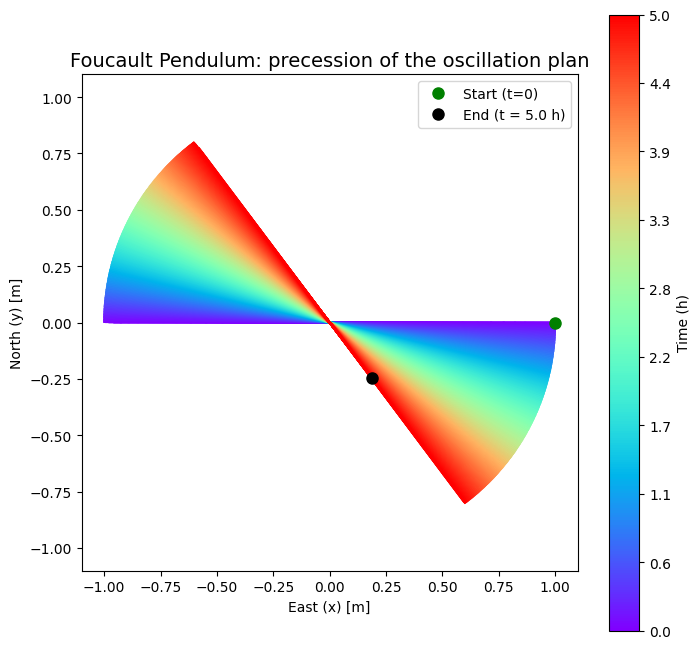

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
g = 9.81
L = 67.0 # Foucault pendulum length (Paris)
phi = np.radians(45.0) # latitude
Omega = 7.2921e-5 # Earth's angular velocity (rad/s)

# Angular velocities
omega_c = Omega * np.sin(phi)
omega_0 = np.sqrt(g / L)
omega_prime = np.sqrt(omega_0**2 + omega_c**2)

# Initial conditions: release from rest at (1,0)
x0, y0 = 1.0, 0.0
xi0 = x0 + 1j * y0

# Time span: 5 hours, clearly shows precession
duration = 5.0 * 60.0 * 60.0   # seconds
t = np.linspace(0, duration, 10_000)

# Exact solution
xi = xi0 * np.exp(-1j * omega_c * t) * (np.cos(omega_prime * t) + 1j * (omega_c / omega_prime) * np.sin(omega_prime * t))
x = np.real(xi) # x(t)
y = np.imag(xi) # y(t)

# Plotting
fig, ax = plt.subplots(figsize = (8, 8))
colors = t / t.max()
points = np.array([x, y]).T.reshape(-1, 2)

for i in range(len(points) - 1):
    ax.plot(points[i : i + 2, 0], points[i : i + 2, 1],
            color = plt.cm.rainbow(colors[i]), lw = 1.5, alpha = 0.8)

ax.plot(x[0], y[0], 'go', markersize = 8, label = 'Start (t=0)')
ax.plot(x[-1], y[-1], 'ko', markersize = 8, label = f'End (t = {duration / 3600.0:.1f} h)')
ax.set_aspect('equal')
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.grid(False)
ax.set_xlabel('East (x) [m]', fontsize = 10)
ax.set_ylabel('North (y) [m]', fontsize = 10)
ax.set_title('Foucault Pendulum: precession of the oscillation plan', fontsize = 14)
ax.legend(loc = 'upper right')

sm = plt.cm.ScalarMappable(cmap = plt.cm.rainbow, norm = plt.Normalize(0, t.max()))
cbar = plt.colorbar(sm, ax = ax, label = 'Time (h)')
num_ticks = 10
tick_seconds = np.linspace(0, t.max(), num_ticks)
tick_labels = [f'{s / (60 * 60):.1f}' for s in tick_seconds]
cbar.set_ticks(tick_seconds)
cbar.set_ticklabels(tick_labels)
plt.show()